<a href="https://colab.research.google.com/github/chrishg23-jpg/HES-benchmark/blob/main/HES18Sim003.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

def spectral_laplacian(shape):
    k_axes = [np.fft.fftfreq(n) for n in shape]
    K = np.meshgrid(*k_axes, indexing='ij')
    k2 = np.zeros(shape, dtype=np.float64)
    for Ki in K: k2 += Ki**2
    return - (2*np.pi)**2 * k2

def grad_sq(u):
    g2 = np.zeros_like(u, dtype=u.dtype)
    for a in range(u.ndim):
        diff = np.roll(u, -1, axis=a) - u
        g2 += diff.astype(u.dtype)**2
    return g2

def initialize_u(D, N, seed=0, ic="spike", dtype=np.float32):
    rng = np.random.default_rng(seed)
    u = np.zeros([N]*D, dtype=dtype)
    if ic == "spike":
        u[tuple([N//2]*D)] = dtype(1.0)
    elif ic == "gaussian":
        xs = np.meshgrid(*[np.arange(N)]*D, indexing='ij')
        r2 = sum(((x - N//2)**2 for x in xs))
        u = np.exp(-r2/(2*(N/8)**2)).astype(dtype)
    elif ic == "random":
        u = rng.standard_normal([N]*D).astype(dtype)
    u += dtype(0.01) * rng.standard_normal([N]*D).astype(dtype)
    return u

def measure_lambda(u):
    F = np.fft.fftn(u); F.flat[0] = 0
    P = np.abs(F)**2; P = np.fft.fftshift(P)
    k_axes = [np.fft.fftshift(np.fft.fftfreq(n)) for n in u.shape]
    K = np.meshgrid(*k_axes, indexing='ij')
    k_mag = np.sqrt(sum(Ki**2 for Ki in K))
    idx = np.unravel_index(np.argmax(P), P.shape)
    k_peak = k_mag[idx]
    return 1.0 / max(k_peak, 1e-12), float(k_peak)

def radial_spectrum(u, bins=40):
    F = np.fft.fftn(u); P = np.abs(F)**2
    P = np.fft.fftshift(P)
    freqs = [np.fft.fftshift(np.fft.fftfreq(n)) for n in u.shape]
    K = np.meshgrid(*freqs, indexing='ij')
    k_mag = np.sqrt(sum(Ki**2 for Ki in K))
    k_bins = np.linspace(0, k_mag.max(), bins)
    S_rad = np.zeros(len(k_bins)-1)
    for i in range(len(k_bins)-1):
        mask = (k_mag >= k_bins[i]) & (k_mag < k_bins[i+1])
        S_rad[i] = P[mask].mean() if np.any(mask) else 0.0
    k_centers = 0.5 * (k_bins[:-1] + k_bins[1:])
    return k_centers, S_rad

def evolve_rescaled(
    D=4, N=24, alpha=0.2, beta=0.0005, gamma=1e-4, S0=50.0,
    steps=2000, sample_every=10, seed=0, cfl=0.02,
    dtype=np.float32, ic="spike", measure_every_step=False
):
    beta_eff, gamma_eff = beta*S0**2, gamma*S0**4
    u = initialize_u(D, N, seed=seed, ic=ic, dtype=dtype)
    lap_op = spectral_laplacian(u.shape).astype(np.float64)
    dt = float(cfl / (alpha * np.max(-lap_op)))
    denom = (1.0 - dt * alpha * lap_op)

    u_rms, u_max, lam_series, E_series, k_series = [], [], [], [], []
    lam_trace = []

    for t in range(steps):
        nl = - beta_eff * (u**3).astype(dtype) - gamma_eff * (u**5).astype(dtype)
        Fu = np.fft.fftn(u)
        Fnl = np.fft.fftn(nl)
        u = np.fft.ifftn((Fu + dt * Fnl) / denom).real.astype(dtype)

        if not np.isfinite(u).all(): raise RuntimeError("Non-finite values encountered.")
        if measure_every_step:
            lam0, _ = measure_lambda(u)
            lam_trace.append(lam0)

        if (t+1) % sample_every == 0:
            ur = float(np.sqrt(np.mean(u**2)))
            umax = float(np.max(np.abs(u)))
            lam0, k0 = measure_lambda(u)
            E_total = (0.5*np.sum(u**2)
                       + 0.5*alpha*np.sum(grad_sq(u))
                       - 0.25*beta_eff*np.sum(u**4)
                       - (1/6)*gamma_eff*np.sum(u**6))
            u_rms.append(ur); u_max.append(umax)
            lam_series.append(lam0); k_series.append(k0); E_series.append(float(E_total))

    lam_arr = np.array(lam_series)
    window = min(50, len(lam_arr)-1) if len(lam_arr) > 1 else 1
    lam_drift = (lam_arr[-1] - lam_arr[-window]) / max(1, window)
    lam_var = float(np.var(lam_arr[-window:])) if len(lam_arr) >= window else 0.0

    return {
        "u_rms": np.array(u_rms), "u_max": np.array(u_max),
        "lambda0": lam_arr, "k_peak": np.array(k_series),
        "energy": np.array(E_series), "dt": dt,
        "beta_eff": beta_eff, "gamma_eff": gamma_eff,
        "lam_drift_per_sample": lam_drift, "lam_var": lam_var,
        "u_rms_floor": float(u_rms[-1]) if len(u_rms) else np.nan,
        "u_snapshot": u, "lam_trace": np.array(lam_trace)
    }


float32: u_rms_floor=0.000389, λ₀_end=10.667
float64: u_rms_floor=0.00038929, λ₀_end=10.667


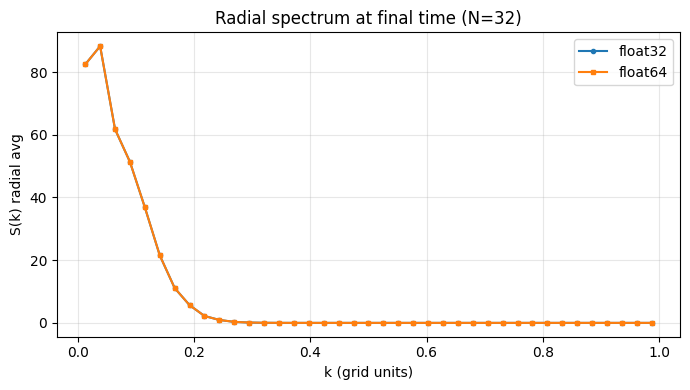

In [ ]:
out32f32 = evolve_rescaled(N=32, steps=2000, sample_every=10, dtype=np.float32)
out32f64 = evolve_rescaled(N=32, steps=2000, sample_every=10, dtype=np.float64)

print(f"float32: u_rms_floor={out32f32['u_rms_floor']:.6f}, λ₀_end={out32f32['lambda0'][-1]:.3f}")
print(f"float64: u_rms_floor={out32f64['u_rms_floor']:.8f}, λ₀_end={out32f64['lambda0'][-1]:.3f}")

k32, S32 = radial_spectrum(out32f32["u_snapshot"])
k64, S64 = radial_spectrum(out32f64["u_snapshot"])

plt.figure(figsize=(7,4))
plt.plot(k32, S32, '-o', ms=3, label='float32')
plt.plot(k64, S64, '-s', ms=3, label='float64')
plt.xlabel("k (grid units)"); plt.ylabel("S(k) radial avg")
plt.title("Radial spectrum at final time (N=32)")
plt.legend(); plt.grid(True, alpha=0.3); plt.tight_layout(); plt.show()


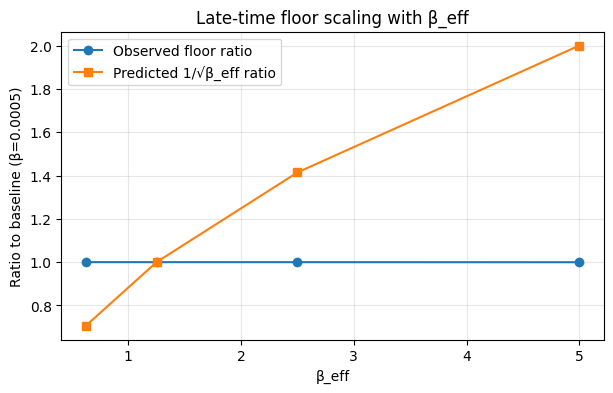

In [ ]:
betas = [0.00025, 0.0005, 0.001, 0.002]
alpha, S0 = 0.2, 50.0
baseline_floor = None
results = []

for beta in betas:
    out = evolve_rescaled(N=32, beta=beta, gamma=1e-4, S0=S0,
                          steps=2000, sample_every=10, dtype=np.float64)
    beta_eff = beta * S0**2
    pred_raw = (alpha / beta_eff)**0.5
    floor = out["u_rms_floor"]
    if beta == 0.0005: baseline_floor = floor
    results.append((beta_eff, floor, pred_raw))

ratios_obs = [f / baseline_floor for _, f, _ in results]
ratios_pred = [results[1][2] / p for _, _, p in results]
beta_eff_vals = [b for b, _, _ in results]

plt.figure(figsize=(7,4))
plt.plot(beta_eff_vals, ratios_obs, '-o', label='Observed floor ratio')
plt.plot(beta_eff_vals, ratios_pred, '-s', label='Predicted 1/√β_eff ratio')
plt.xlabel("β_eff"); plt.ylabel("Ratio to baseline (β=0.0005)")
plt.title("Late-time floor scaling with β_eff")
plt.grid(True, alpha=0.3); plt.legend();


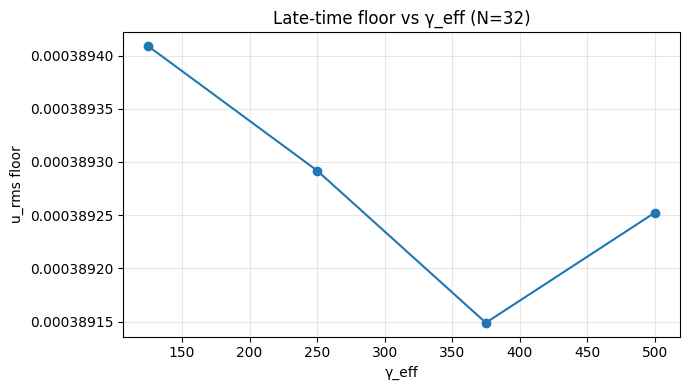

γ_eff, floor, λ₀_end:
125.0, 0.000389, 22.627
250.0, 0.000389, 10.667
375.0, 0.000389, 10.667
500.0, 0.000389, 10.667


In [ ]:
# --- Floor scaling with γ (quintic) ---
gammas = [2e-5, 4e-5, 6e-5, 8e-5]  # γ_eff ∈ [125, 250, 375, 500]

alpha, beta, S0 = 0.2, 0.0005, 50.0
results_g = []

for gamma in gammas:
    out = evolve_rescaled(N=32, beta=beta, gamma=gamma, S0=S0,
                          steps=2000, sample_every=10, dtype=np.float64)
    results_g.append((gamma*S0**4, out["u_rms_floor"], out["lambda0"][-1]))

# Plot floor vs γ_eff
plt.figure(figsize=(7,4))
plt.plot([g for g, _, _ in results_g],
         [f for _, f, _ in results_g], '-o')
plt.xlabel("γ_eff"); plt.ylabel("u_rms floor")
plt.title("Late-time floor vs γ_eff (N=32)")
plt.grid(True, alpha=0.3); plt.tight_layout(); plt.show()

print("γ_eff, floor, λ₀_end:")
for g_eff, floor, lam in results_g:
    print(f"{g_eff:.1f}, {floor:.6f}, {lam:.3f}")


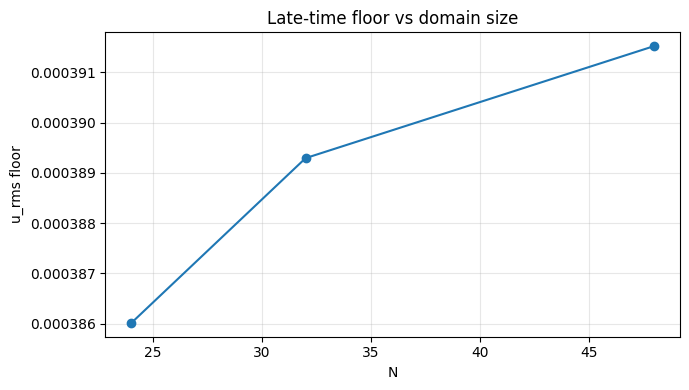

N, floor, λ₀_end:
24, 0.000386, 9.798
32, 0.000389, 10.667
48, 0.000392, 11.642


In [ ]:
# --- Floor vs domain size (N) ---
Ns = [24, 32, 48]
alpha, beta, gamma, S0 = 0.2, 0.0005, 1e-4, 50.0
res_N = []
for N in Ns:
    out = evolve_rescaled(N=N, beta=beta, gamma=gamma, S0=S0,
                          steps=2000, sample_every=10, dtype=np.float64)
    res_N.append((N, out["u_rms_floor"], out["lambda0"][-1]))

plt.figure(figsize=(7,4))
plt.plot([N for N, _, _ in res_N],
         [f for _, f, _ in res_N], '-o')
plt.xlabel("N"); plt.ylabel("u_rms floor")
plt.title("Late-time floor vs domain size")
plt.grid(True, alpha=0.3); plt.tight_layout(); plt.show()

print("N, floor, λ₀_end:")
for N, floor, lam in res_N:
    print(f"{N}, {floor:.6f}, {lam:.3f}")


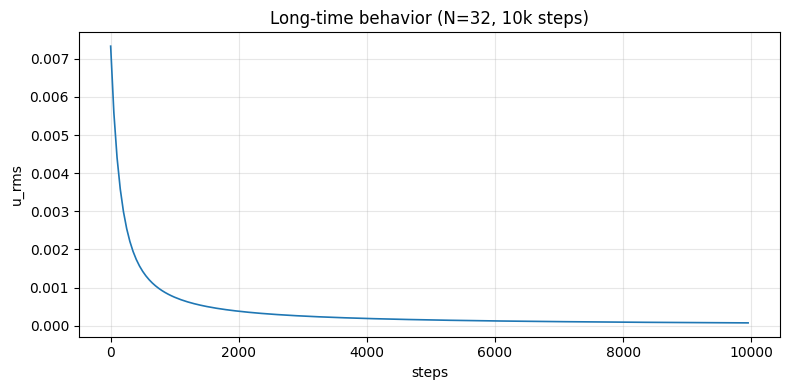

Late-time u_rms_floor=0.000075, λ₀_end=22.627, lam_drift=0.000000, lam_var=0.000000


In [ ]:
# --- Long-time equilibrium test ---
outL = evolve_rescaled(N=32, beta=0.0005, gamma=1e-4, S0=50.0,
                       steps=10000, sample_every=50, dtype=np.float64)
ts = np.arange(len(outL["u_rms"])) * 50

plt.figure(figsize=(8,4))
plt.plot(ts, outL["u_rms"], lw=1.2)
plt.xlabel("steps"); plt.ylabel("u_rms")
plt.title("Long-time behavior (N=32, 10k steps)")
plt.grid(True, alpha=0.3); plt.tight_layout(); plt.show()

print(f"Late-time u_rms_floor={outL['u_rms_floor']:.6f}, "
      f"λ₀_end={outL['lambda0'][-1]:.3f}, "
      f"lam_drift={outL['lam_drift_per_sample']:.6f}, "
      f"lam_var={outL['lam_var']:.6f}")


/tmp/ipython-input-620361544.py:10: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  lowk_power = np.trapz(Srad[lowk_mask], k[lowk_mask])


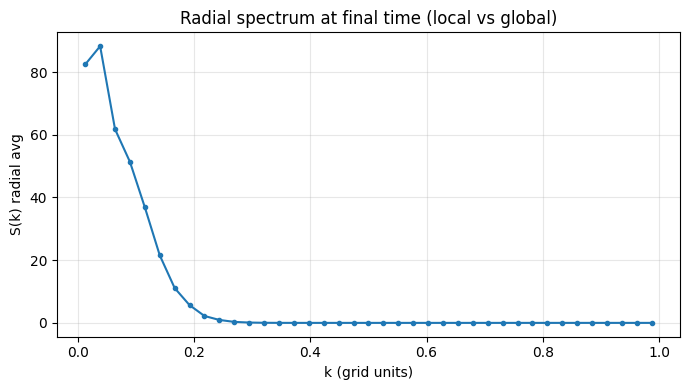

u_rms=0.000389, u_max=0.002051, low-k integrated power≈7.443


In [ ]:
# --- Local vs global: peak vs rms, low-k power ---
out = evolve_rescaled(N=32, beta=0.0005, gamma=1e-4, S0=50.0,
                      steps=2000, sample_every=10, dtype=np.float64)
u = out["u_snapshot"]
k, Srad = radial_spectrum(u)

u_rms = out["u_rms_floor"]
u_max = float(np.max(np.abs(u)))
lowk_mask = k < (0.15)  # around observed peak
lowk_power = np.trapz(Srad[lowk_mask], k[lowk_mask])

plt.figure(figsize=(7,4))
plt.plot(k, Srad, '-o', ms=3)
plt.xlabel("k (grid units)"); plt.ylabel("S(k) radial avg")
plt.title("Radial spectrum at final time (local vs global)")
plt.grid(True, alpha=0.3); plt.tight_layout(); plt.show()

print(f"u_rms={u_rms:.6f}, u_max={u_max:.6f}, low-k integrated power≈{lowk_power:.3f}")
